In [1]:
import torch
import torch.optim as optim
import numpy as np
from tqdm import tqdm
import datetime
from prettytable import PrettyTable

if torch.cuda.is_available():
    print(f"cuda available")
    device = 'cuda'
else:
    print(f"cuda not available")
    device = 'cpu'

import sys
sys.path.append('/home/m.caros/work/3DSemanticSegmentation')

from utils.utils import *
from utils.utils_plot import *
from utils.get_metrics import *
from src.datasets import CAT3Dataset
from src.config import *
from utils.utils import *
from utils.get_metrics import *
from src.LoRA.models.pointnet2_ss import *
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


cuda available


2025-12-23 11:55:21 INFO     Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
2025-12-23 11:55:21 INFO     NumExpr defaulting to 8 threads.


In [80]:
# dir_path = '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/confusion_matrices'
# matching_files = list(Path(dir_path).rglob("CM_B29*02-24-15:52*")) # done
# matching_files = list(glob.glob(dir_path + "/CM_RIB*02-24-15:52*")) # done mIou=71.6

# dir_path = '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_RIB/confusion_matrices_old'
# dir_path = '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_RIB/confusion_matrices'
# matching_files = list(glob.glob(dir_path + "/*07-23-12:12_32R32alph168000*"))
# matching_files = list(glob.glob(dir_path + "/*04-29-18:01*")) #done FT

# dir_path = '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/confusion_matrices'
# IoU-results-seg_11-05-13:19ribPN++
# matching_files = list(glob.glob(dir_path + "/*11-05-13:19*")) # done
# matching_files = list(glob.glob(dir_path + "/*07-25-12:37_64R64alph168*")) #Mean IoU: 81.2, tower: 70.7, power lines: 72.8
# matching_files = list(glob.glob(dir_path + "/*07-26-16:22_64R64alph168*")) #mean IoU: 80.9
# matching_files = list(glob.glob(dir_path + "/*08-01-20:34_64R64alph168*")) 
# matching_files = list(glob.glob(dir_path + "/*07-31-10:13_32R32alph32*")) 
# matching_files = list(glob.glob(dir_path + "/*08-01-10:07_32R32alph64*")) 
# matching_files = list(glob.glob(dir_path + "/*07-31-10:13_32R32alph32*")) 
# matching_files = list(glob.glob(dir_path + "/*11-08-10:05_128R128alph168*")) 
# matching_files = list(glob.glob(dir_path + "/*seg_11-05-13:33B29_PN++_w*")) 
# matching_files = list(glob.glob(dir_path + "/*seg_11-10-10:12ribPN++*")) 

# Results_B29_trainedRIB
# dir_path='/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_B29_trainedRIB/confusion_matrices'
# matching_files = list(glob.glob(dir_path + "/CM_seg_04-29-18:01lr0001RIB_*")) 
# matching_files = list(glob.glob(dir_path + "/CM_loraPN2_07-26-16:22_64R64alph1616000B29_*")) # not best
# matching_files = list(glob.glob(dir_path + "/CM_loraPN2_07-25-12:37_64R64alph1616000B29_*")) # not best
# matching_files = list(glob.glob(dir_path + "/CM_loraPN2_07-23-12:12_32R32alph168000B29_*"))
# matching_files = list(glob.glob(dir_path + "/CM_loraPN2_07-25-12:58_32R32alph1616000B29_*"))

# DALES
dir_path = '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/'
matching_files = list(glob.glob(dir_path + "/CM_DALES_16000p_seg_02-10-11:21_base_*"))
# src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_8000p_seg_02-13-10:31_lora_32R_32T4_54325.txt
# matching_files = list(glob.glob(dir_path + "/CM_DALES_8000p_seg_02-13-10:31_lora_32R_32T4_*"))
# src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_8000p_seg_02-13-10:33_FTT4_54325.txt
# matching_files = list(glob.glob(dir_path + "/CM_DALES_8000p_seg_02-13-10:33_FTT4_*"))




In [81]:
np.sort(matching_files)


array(['/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54325.txt',
       '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54335.txt',
       '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54390.txt',
       '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54395.txt',
       '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54400.txt',
       '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54430.txt',
       '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DAL

In [82]:
np.sort(matching_files)


array(['/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54325.txt',
       '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54335.txt',
       '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54390.txt',
       '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54395.txt',
       '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54400.txt',
       '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54430.txt',
       '/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DAL

In [83]:
# name_list= matching_files[0]._str.split('/')[-1].split('_')[:6]
name_list= matching_files[0].split('/')[-1].split('_')[:5]

In [84]:
name = '_'.join(map(str, name_list)).split('.')[0]
print(name)

CM_DALES_16000p_seg_02-10-11:21


/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54430.txt
/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54325.txt
/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54395.txt
/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54470.txt
/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54435.txt
/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54400.txt
/home/m.caros/work/3DSemanticSegmentation/src/LoRA/metrics/results_DALES/confusion_matrices/CM_DALES_16000p_seg_02-10-11:21_base_54440.txt
/home/m.caros/work/3DSemant

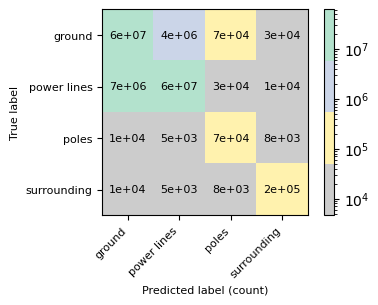

Saved to cm_figures/CM_DALES_16000p_seg_02-10-11:21_norm


<Figure size 640x480 with 0 Axes>

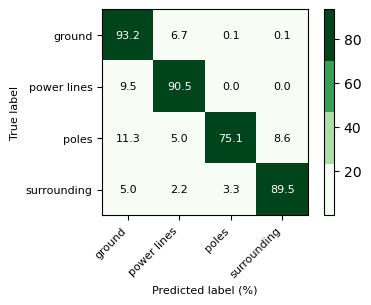

In [86]:
# classes=['surrounding', 'tower', 'power lines', 'wind turbine']
# classes=['surrounding', 'tower', 'power lines']

classes=['ground',  'power lines', 'poles', 'surrounding'] #DALES
# classes=['ground', 'poles', 'power lines', 'surrounding', 'buildings', 'cars'] # DALES LoRA FT

N_CLASSES = len(classes)

cm_sum = np.zeros((N_CLASSES, N_CLASSES))

for file in matching_files:
    print(file)
    with open(file, 'r') as f:
        cm = np.array(eval(f.read()))
    cm_sum = cm_sum + cm[:N_CLASSES,:N_CLASSES]
    cm_sum = cm_sum.astype(int)

show_confusion_matrix(cm_sum[:N_CLASSES,:N_CLASSES], classes, 
                      fontsize=8, plot_bar=True, log_scale=True, cmap='Pastel2_r', title='',
                      save_path=f'cm_figures/{name}',n_colors = 4)
plt.figure()
show_confusion_matrix(cm_sum[:N_CLASSES,:N_CLASSES], classes, 
# show_confusion_matrix(cm_sum, classes=['surrounding', 'tower', 'power lines'], 
                      normalize=True, plot_bar=True, cmap='Greens', title='',
                      fontsize=8, save_path=f'cm_figures/{name}_norm')
plt.show()

In [87]:
cm_sum

array([[62141265,  4455671,    72753,    34409],
       [ 6503403, 62261710,    33222,    10432],
       [   10451,     4598,    69610,     7972],
       [   11599,     4977,     7583,   205954]])

In [53]:
cm_sum

array([[62141265,  4455671,    72753,    34409],
       [ 6503403, 62261710,    33222,    10432],
       [   10451,     4598,    69610,     7972],
       [   11599,     4977,     7583,   205954]])

In [54]:
# Use only the classes we need
cm_subset = cm_sum[:N_CLASSES, :N_CLASSES].astype(int)

# Calculate F1 scores directly from confusion matrix (much faster!)
# True Positives (diagonal elements)
tp = np.diag(cm_subset)

# False Positives (sum of column - TP)
fp = cm_subset.sum(axis=0) - tp

# False Negatives (sum of row - TP)
fn = cm_subset.sum(axis=1) - tp

# Precision and Recall
precision = tp / (tp + fp)
recall = tp / (tp + fn)

# F1 score per class
f1_per_class = 2 * (precision * recall) / (precision + recall)

# Macro F1 (average of F1 scores)
f1_macro = np.nanmean(f1_per_class)  # nanmean handles division by zero

# print(f"F1-Score (Macro): {f1_macro:.4f}")


In [55]:
print(f"\nF1-Score per class:")
for i, cls in enumerate(classes):
    print(f"  {cls}: {f1_per_class[i]*100:.2f}")
print(f"\nF1-Score (Macro): {f1_macro*100:.2f}")

# Calculate IoU (Intersection over Union) per class
iou_per_class = tp / (tp + fp + fn)

# Mean IoU
mean_iou = np.nanmean(iou_per_class)

print(f"\nMean IoU: {mean_iou*100:.2f}")
print(f"IoU per class:")
for i, cls in enumerate(classes):
    print(f"  {cls}: {iou_per_class[i]*100:.2f}")




F1-Score per class:
  ground: 91.81
  power lines: 91.87
  poles: 50.48
  surrounding: 84.26

F1-Score (Macro): 79.60

Mean IoU: 69.10
IoU per class:
  ground: 84.86
  power lines: 84.97
  poles: 33.76
  surrounding: 72.79


In [56]:
# Calculate accuracy per class (recall/sensitivity)
accuracy_per_class = np.diag(cm_sum) / cm_sum.sum(axis=1)
acc_mean = np.nanmean(accuracy_per_class)  # nanmean handles division by zero


print("Accuracy per class:")
for i, cls in enumerate(classes):
    print(f"  {cls}: {accuracy_per_class[i]:.4f}")

print(f"Acc mean: {acc_mean:.4f}")
# Calculate overall accuracy
overall_accuracy = np.trace(cm_sum) / np.sum(cm_sum)

print(f"Overall Accuracy: {overall_accuracy:.4f}")

Accuracy per class:
  ground: 0.9316
  power lines: 0.9049
  poles: 0.7515
  surrounding: 0.8950
Acc mean: 0.8707
Overall Accuracy: 0.9179
